# Test the supplied CSV with the saved CPH4 model

This notebook runs inference on the original `ai4i2020.csv` and compares predictions with its actual `Machine failure` labels. It does not fit, tune, or replace any model. The original split manifest identifies training, validation, and held-out test rows. **Whole-file scores include training observations and are not generalization estimates.** The held-out result is a repeat verification of the existing test set, not a new independent test.

Only the six approved input columns are passed to the production inference engine. IDs are retained solely to trace results back to the CSV; failure flags and the actual binary target are never supplied as inputs.

In [1]:
from pathlib import Path
import sys
import json
import hashlib

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "backend/inference.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss
from backend.config import FIELD_MAP
from backend.inference import PredictionEngine
from backend.schemas import MachineReading

source = ROOT / "ai4i2020.csv"
if not source.exists():
    source = ROOT / "data/raw/ai4i2020.csv"
raw_bytes = source.read_bytes()
digest = hashlib.sha256(raw_bytes).hexdigest()
records = pd.read_csv(source, encoding="utf-8-sig")
manifest = json.loads((ROOT / "data/processed/split_manifest.json").read_text())
engine = PredictionEngine(ROOT / "models")
assert digest == manifest["source_sha256"] == engine.metadata["dataset_sha256"]
assert set(FIELD_MAP.values()).issubset(records.columns)
assert records["Machine failure"].isin([0, 1]).all()
print(f"Input: {source.name}; {len(records):,} rows; {records['Machine failure'].sum()} actual failures")
print("Model:", engine.metadata["model_version"])
print("Decision threshold:", engine.metadata["decision_threshold"])


/run/media/jadeite/Local Disk/Predictive Maintenance AI Platform/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input: ai4i2020.csv; 10,000 rows; 339 actual failures
Model: ai4i-f3eb2ed3aaf9
Decision threshold: 0.08567804843187332


In [2]:
# Use the production input validation and saved pipeline without writing to application history.
readings = [MachineReading.model_validate({field: row[raw] for field, raw in FIELD_MAP.items()})
            for row in records.to_dict(orient="records")]
predictions = []
for start in range(0, len(readings), 500):
    predictions.extend(engine.predict(readings[start:start + 500]))
assert len(predictions) == len(records)

partitions = pd.Series(index=records.index, dtype="string")
all_indices = []
for partition in ("train", "validation", "test"):
    indices = manifest[partition]
    partitions.iloc[indices] = partition
    all_indices.extend(indices)
assert sorted(all_indices) == list(range(len(records)))
results = records[["UDI", "Product ID", *FIELD_MAP.values()]].copy()
results["partition"] = partitions
results["actual_failure"] = records["Machine failure"]
results["failure_probability"] = [p["failure_probability"] for p in predictions]
results["predicted_failure"] = [p["prediction"] for p in predictions]
results["risk_level"] = [p["risk_level"] for p in predictions]
results["model_version"] = engine.metadata["model_version"]
results["warnings"] = ["; ".join(p["warnings"]) for p in predictions]
results["outcome"] = np.select([
    (results.actual_failure == 1) & (results.predicted_failure == 1),
    (results.actual_failure == 0) & (results.predicted_failure == 1),
    (results.actual_failure == 1) & (results.predicted_failure == 0),
], ["true_positive", "false_positive", "false_negative"], default="true_negative")
assert results.failure_probability.between(0, 1).all()
print(f"Validated and scored all {len(results):,} rows through the production inference engine.")
display(results.head(10))


Validated and scored all 10,000 rows through the production inference engine.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],partition,actual_failure,failure_probability,predicted_failure,risk_level,model_version,warnings,outcome
0,1,M14860,M,298.1,308.6,1551,42.8,0,train,0,0.000059,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
1,2,L47181,L,298.2,308.7,1408,46.3,3,test,0,0.001557,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
2,3,L47182,L,298.1,308.5,1498,49.4,5,train,0,0.000151,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
3,4,L47183,L,298.2,308.6,1433,39.5,7,train,0,0.000594,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
4,5,L47184,L,298.2,308.7,1408,40.0,9,validation,0,0.000548,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
5,6,M14865,M,298.1,308.6,1425,41.9,11,validation,0,0.000181,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
6,7,L47186,L,298.1,308.6,1558,42.4,14,test,0,0.000059,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
7,8,L47187,L,298.1,308.6,1527,40.2,16,validation,0,0.000137,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
8,9,M14868,M,298.3,308.7,1667,28.6,18,train,0,0.000968,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative
9,10,M14869,M,298.5,309.0,1741,28.0,21,test,0,0.000572,0,healthy,ai4i-f3eb2ed3aaf9,,true_negative


In [3]:
def measure(frame, label):
    actual, predicted, probability = frame.actual_failure, frame.predicted_failure, frame.failure_probability
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    return {"partition": label, "rows": len(frame), "actual_failures": int(actual.sum()),
            "predicted_failures": int(predicted.sum()), "true_positives": int(tp),
            "false_positives": int(fp), "false_negatives": int(fn), "true_negatives": int(tn),
            "precision": float(precision_score(actual, predicted, zero_division=0)),
            "recall": float(recall_score(actual, predicted, zero_division=0)),
            "f1": float(f1_score(actual, predicted, zero_division=0)),
            "roc_auc": float(roc_auc_score(actual, probability)),
            "pr_auc": float(average_precision_score(actual, probability)),
            "brier_score": float(brier_score_loss(actual, probability))}

summaries = [measure(results[results.partition == part], part) for part in ("train", "validation", "test")]
summaries.append(measure(results, "all_rows_includes_training"))
summary = pd.DataFrame(summaries)
display(summary)
held_out = results[results.partition == "test"].copy()
current = next(item for item in summaries if item["partition"] == "test")
previous = json.loads((ROOT / "reports/metrics/final_evaluation.json").read_text())
assert previous["model_version"] == engine.metadata["model_version"]
for metric in ("precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score"):
    np.testing.assert_allclose(current[metric], previous["metrics"][metric], rtol=1e-6, atol=1e-8)
np.testing.assert_array_equal(confusion_matrix(held_out.actual_failure, held_out.predicted_failure), previous["metrics"]["confusion_matrix"])
print("Held-out metrics reproduce the original final evaluation.")
print(f"Test: detected {current['true_positives']} of {current['actual_failures']} failures; "
      f"missed {current['false_negatives']}; false alarms {current['false_positives']}.")


,partition,rows,actual_failures,predicted_failures,true_positives,false_positives,false_negatives,true_negatives,precision,recall,f1,roc_auc,pr_auc,brier_score
0,train,6000,203,412,203,209,0,5588,0.492718,1.000000,0.660163,0.999942,0.998400,0.002623
1,validation,2000,68,138,62,76,6,1856,0.449275,0.911765,0.601942,0.972567,0.804986,0.012475
2,test,2000,68,143,58,85,10,1847,0.405594,0.852941,0.549763,0.980560,0.770586,0.013441
3,all_rows_includes_training,10000,339,693,323,370,16,9291,0.466089,0.952802,0.625969,0.990706,0.922002,0.006757


Held-out metrics reproduce the original final evaluation.
Test: detected 58 of 68 failures; missed 10; false alarms 85.


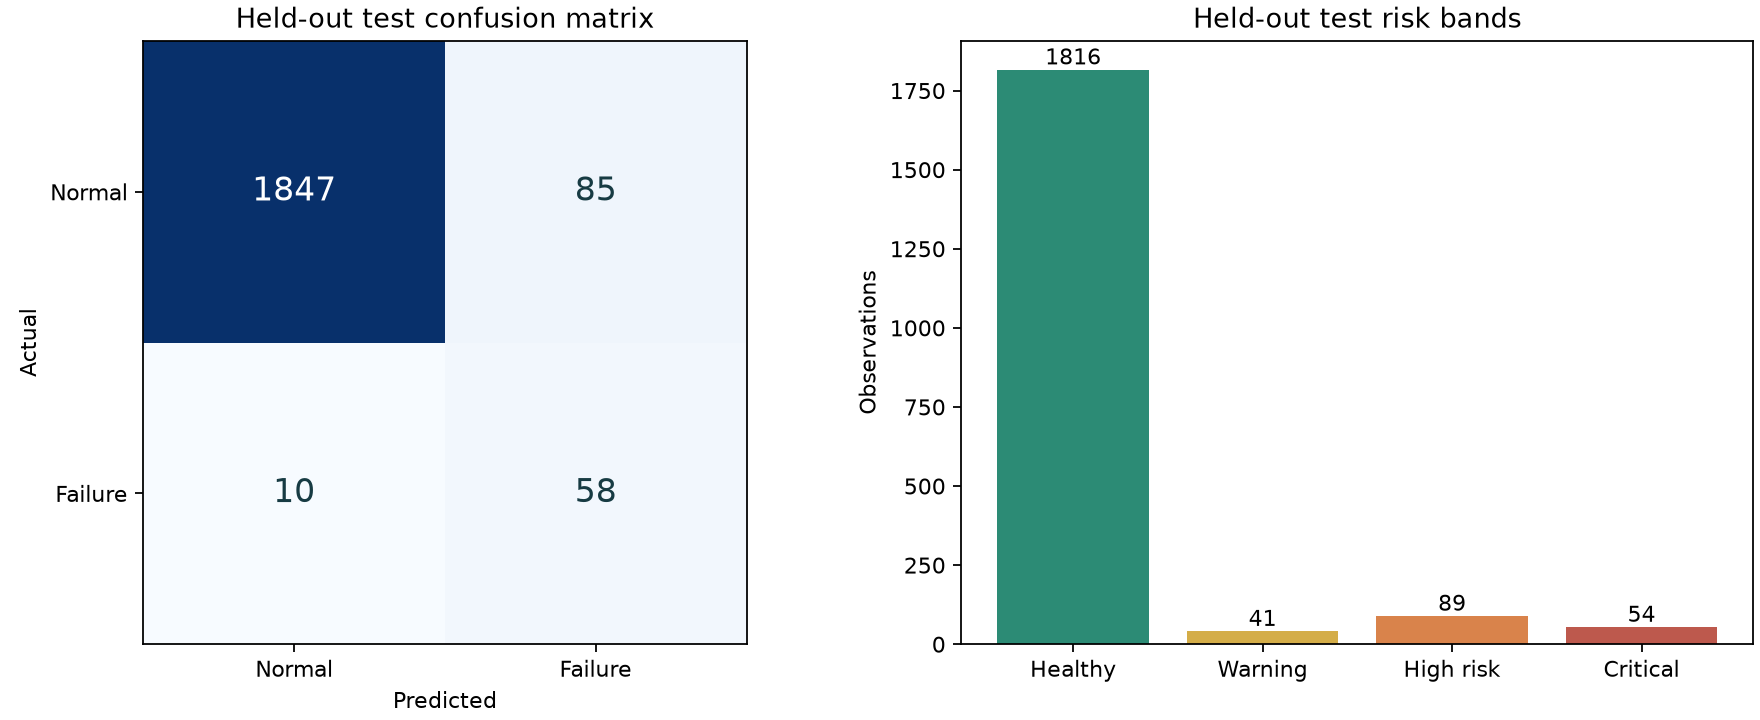

Missed failures in the held-out partition:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],partition,actual_failure,failure_probability,predicted_failure,risk_level,outcome
586,587,L47766,L,297.6,309.6,1501,49.8,222,test,1,0.048540,0,warning,false_negative
1492,1493,M16352,M,298.0,308.7,1479,58.5,176,test,1,0.003964,0,healthy,false_negative
2166,2167,M17026,M,299.6,309.2,1867,23.4,225,test,1,0.067802,0,warning,false_negative
2244,2245,M17104,M,299.3,308.4,1542,37.5,203,test,1,0.004515,0,healthy,false_negative
3695,3696,L50875,L,302.2,311.3,1530,37.3,207,test,1,0.044363,0,warning,false_negative
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,test,1,0.004316,0,healthy,false_negative
4778,4779,H34192,H,303.6,312.2,1371,54.6,112,test,1,0.064861,0,warning,false_negative
6256,6257,L53436,L,301.0,310.6,1493,37.8,206,test,1,0.016980,0,healthy,false_negative
7087,7088,L54267,L,300.6,310.3,1648,30.5,217,test,1,0.063206,0,warning,false_negative
7884,7885,L55064,L,300.8,312.4,1465,59.1,91,test,1,0.016976,0,healthy,false_negative


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
cm = confusion_matrix(held_out.actual_failure, held_out.predicted_failure, labels=[0, 1])
axes[0].imshow(cm, cmap="Blues")
for (row, column), value in np.ndenumerate(cm):
    axes[0].text(column, row, str(value), ha="center", va="center", fontsize=15,
                 color="white" if value > cm.max() / 2 else "#173b43")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Normal", "Failure"],
            yticklabels=["Normal", "Failure"], xlabel="Predicted", ylabel="Actual",
            title="Held-out test confusion matrix")
counts = held_out.risk_level.value_counts().reindex(["healthy", "warning", "high_risk", "critical"], fill_value=0)
axes[1].bar(["Healthy", "Warning", "High risk", "Critical"], counts, color=["#2c8b75", "#d4ad48", "#d9834b", "#bd594d"])
axes[1].set(ylabel="Observations", title="Held-out test risk bands")
for i, value in enumerate(counts):
    axes[1].text(i, value, str(value), ha="center", va="bottom")
figure_path = ROOT / "reports/figures/supplied_csv_test.png"
fig.savefig(figure_path, dpi=160)
plt.close(fig)
display(Image(filename=str(figure_path)))
print("Missed failures in the held-out partition:")
display(held_out[held_out.outcome == "false_negative"].drop(columns=["model_version", "warnings"]))


In [5]:
output = ROOT / "reports/predictions"
output.mkdir(parents=True, exist_ok=True)
results.to_csv(output / "supplied_csv_all_predictions.csv", index=False)
held_out.to_csv(output / "supplied_csv_held_out_predictions.csv", index=False)
summary.to_csv(output / "supplied_csv_scores.csv", index=False)
report = {"source": str(source.relative_to(ROOT)), "dataset_sha256": digest,
          "model_version": engine.metadata["model_version"],
          "threshold": engine.metadata["decision_threshold"], "scores": summaries,
          "note": "Whole-file results include training data. Test results repeat the original frozen held-out evaluation; no refitting or tuning performed."}
(output / "supplied_csv_test_report.json").write_text(json.dumps(report, indent=2) + "\n")
assert hashlib.sha256(source.read_bytes()).hexdigest() == digest
print("Saved row-level predictions, per-partition scores, and test report:", output)


Saved row-level predictions, per-partition scores, and test report: /run/media/jadeite/Local Disk/Predictive Maintenance AI Platform/reports/predictions


## Interpretation

Use the **test** row for the existing held-out evaluation. The all-rows result describes this exact file, including training observations, and should not be advertised as performance on unseen machines. False negatives are actual failures the model missed; false positives are normal observations flagged as failures. Probabilities and risk bands are model estimates. These synthetic observations do not establish a future failure horizon.

No application history was populated by this offline evaluation. Exported prediction files include identifiers and labels for auditing; they are result files, not input templates for the batch-upload page.